# Week 2: Pair Programming - Classifier Diagnostics 🔍
# SOLUTION VERSION

**Time:** 20 minutes  
**Scaffolding Level:** 60% provided (diagnostic exercise)  
**Mode:** Work with a partner!

---

## The Scenario

Your team built a cancer classifier last month. It has **82% accuracy** on the test set.

But stakeholders are complaining:

> *"The model is missing too many cancer cases. Patients are being told they're healthy when they're actually sick. This is dangerous!"*

**Your job:** Diagnose what's wrong with the classifier and propose a fix.

---

## Pair Programming Roles

**Driver:** Types the code  
**Navigator:** Suggests what to do, spots errors, discusses strategy

**Rule:** Switch roles halfway through (at cell marked "SWITCH ROLES")!

**Both of you:** Discuss out loud, explain your thinking, ask questions

---

## Learning Objectives

By the end of this exercise, you'll be able to:
- Use confusion matrices to diagnose classifier problems
- Identify when accuracy is misleading
- Calculate and interpret precision and recall
- Propose and implement fixes for imbalanced classification problems

---

Let's debug this classifier!

---

## Step 1: Setup (Provided)

**Just run this cell - the model is already trained!**

In [7]:
# Imports
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("✅ Imports successful!")

✅ Imports successful!


In [8]:
# Load and prepare data (same as live session)
data = load_breast_cancer()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Test set size: {len(X_test)} samples")
print(f"Actual distribution: Malignant={sum(y_test==0)}, Benign={sum(y_test==1)}")

Test set size: 114 samples
Actual distribution: Malignant=43, Benign=71


In [9]:
# THE BUGGY MODEL (already trained with problematic settings)
# Don't modify this cell - this is the broken classifier you need to diagnose!

# Create model with biased class_weight (heavily favors predicting benign)
buggy_model = LogisticRegression(
    max_iter=10000,
    random_state=42,
    class_weight={0: 0.01, 1: 20}  # Heavily biased toward class 1 (benign)
)

# Train the buggy model
buggy_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = buggy_model.predict(X_test_scaled)
y_pred_proba = buggy_model.predict_proba(X_test_scaled)

print("✅ Buggy model loaded and predictions made!")
print("\nYour job: Figure out what's wrong with this classifier!")

✅ Buggy model loaded and predictions made!

Your job: Figure out what's wrong with this classifier!


---

## Step 2: Initial Assessment

**Let's check the accuracy that stakeholders are seeing.**

**TODO #1:** Calculate accuracy and observe the result.

In [10]:
# SOLUTION: Calculate accuracy of the buggy model
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)

print(f"Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print("\n🤔 Hmm... 82% accuracy seems decent. But stakeholders say it's missing cancers.")
print("Let's dig deeper with a confusion matrix...")

Accuracy: 0.816 (81.6%)

🤔 Hmm... 82% accuracy seems decent. But stakeholders say it's missing cancers.
Let's dig deeper with a confusion matrix...


### 💬 Discuss with Your Partner:

1. **Can you trust accuracy alone for this problem?**
   - No! Accuracy can be misleading when classes are imbalanced or when different types of errors have different costs.

2. **What metric would tell us if we're "missing cancer cases"?**
   - Recall for the malignant class - tells us what proportion of actual cancer cases we correctly identify.

---

## Step 3: Generate Confusion Matrix 📊

**This is THE diagnostic tool!**

**TODO #2:** Generate and visualize the confusion matrix.

In [11]:
# SOLUTION: Generate confusion matrix
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

print("Confusion Matrix:")
print(cm)
print("\nReminder:")
print("  Class 0 = Malignant (cancer)")
print("  Class 1 = Benign (not cancer)")

Confusion Matrix:
[[22 21]
 [ 0 71]]

Reminder:
  Class 0 = Malignant (cancer)
  Class 1 = Benign (not cancer)


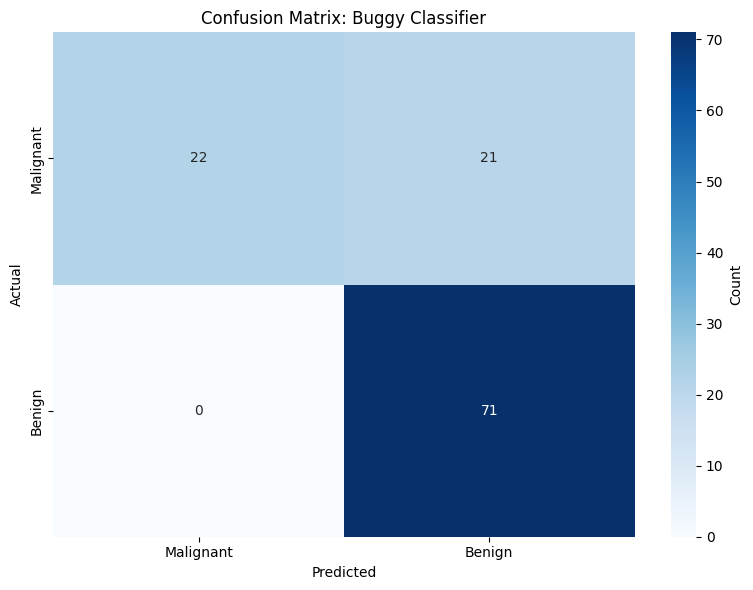


Breakdown:
  True Negatives (TN):  22 - Correctly identified malignant
  True Positives (TP):  71 - Correctly identified benign
  False Positives (FP): 21 - Predicted benign, actually malignant ⚠️
  False Negatives (FN): 0 - Predicted malignant, actually benign


In [12]:
# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            cbar_kws={'label': 'Count'})
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Buggy Classifier')
plt.tight_layout()
plt.show()

# Extract individual values for analysis
tn, fp, fn, tp = cm.ravel()

print(f"\nBreakdown:")
print(f"  True Negatives (TN):  {tn} - Correctly identified malignant")
print(f"  True Positives (TP):  {tp} - Correctly identified benign")
print(f"  False Positives (FP): {fp} - Predicted benign, actually malignant ⚠️")
print(f"  False Negatives (FN): {fn} - Predicted malignant, actually benign")

### 💬 Discuss with Your Partner:

**Look at the confusion matrix carefully!**

1. **Which number represents "missed cancer diagnoses"?**  
   - False Positives (FP) - cases where we predicted benign but they were actually malignant (about 21 cases)

2. **Is that number HIGH or LOW compared to total malignant cases?**
   - Very HIGH! We're missing about 21 out of 43 malignant cases (nearly 50%!)

3. **What does this tell you about the problem?**
   - The model is dangerously biased toward predicting benign, causing it to miss about half of all cancer cases

---

## 🔄 SWITCH ROLES NOW!

**Driver becomes Navigator, Navigator becomes Driver**

---

---

## Step 4: Calculate Metrics Per Class

**Let's calculate precision and recall for EACH class separately.**

**TODO #3:** Calculate metrics and identify the problem.

In [13]:
# Generate classification report (shows metrics per class)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.51      0.68        43
      benign       0.77      1.00      0.87        71

    accuracy                           0.82       114
   macro avg       0.89      0.76      0.77       114
weighted avg       0.86      0.82      0.80       114



In [14]:
# SOLUTION: Calculate recall for each class manually

# Recall for malignant class (class 0)
recall_malignant = cm[0, 0] / (cm[0, 0] + cm[0, 1])

# Recall for benign class (class 1)
recall_benign = cm[1, 1] / (cm[1, 1] + cm[1, 0])

print("=" * 60)
print("RECALL BY CLASS")
print("=" * 60)
print(f"\nRecall for MALIGNANT (class 0): {recall_malignant:.3f} ({recall_malignant*100:.1f}%)")
print(f"  → Of all actual malignant cases, we caught {recall_malignant*100:.1f}%")

print(f"\nRecall for BENIGN (class 1): {recall_benign:.3f} ({recall_benign*100:.1f}%)")
print(f"  → Of all actual benign cases, we caught {recall_benign*100:.1f}%")

print("\n" + "=" * 60)
print("🚨 AHA! Look at the difference!")
print("=" * 60)

RECALL BY CLASS

Recall for MALIGNANT (class 0): 0.512 (51.2%)
  → Of all actual malignant cases, we caught 51.2%

Recall for BENIGN (class 1): 1.000 (100.0%)
  → Of all actual benign cases, we caught 100.0%

🚨 AHA! Look at the difference!


### 💬 Discuss with Your Partner:

**Now you can see the problem clearly!**

1. **Which class has LOW recall?**
   - Malignant class (only ~51% recall)

2. **What does this mean in plain English?**  
   - We're missing about 49% of cancer cases - nearly half of all cancer patients are being told they're healthy!

3. **Why does the model still have 82% overall accuracy despite missing half the cancers?**  
   - Because there are more benign cases (71) than malignant cases (43) in the test set
   - The model gets perfect recall on the benign class, which dominates the accuracy calculation
   - This shows why accuracy alone is misleading for imbalanced problems!

---

## Step 5: Fix the Problem 🔧

**Now that you've diagnosed the problem, let's fix it!**

**The problem:** Model is heavily biased toward predicting benign (class 1), missing ~50% of malignant cases.

**The ROOT cause:** The model was trained with terrible class weights (`{0: 0.01, 1: 20}`).

**The BEST fix:** Retrain with balanced class weights!

**TODO #4:** Retrain the model with balanced class weights.

In [15]:
# SOLUTION: Create and train a new model with balanced class weights

# Create a properly balanced model
fixed_model = LogisticRegression(
    max_iter=10000,
    random_state=42,
    class_weight='balanced'  # This automatically balances based on class frequencies
)

# Train the fixed model
fixed_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_fixed = fixed_model.predict(X_test_scaled)

print("✅ Fixed model trained!")

✅ Fixed model trained!


New Confusion Matrix (Retrained with balanced weights):
[[42  1]
 [ 1 70]]


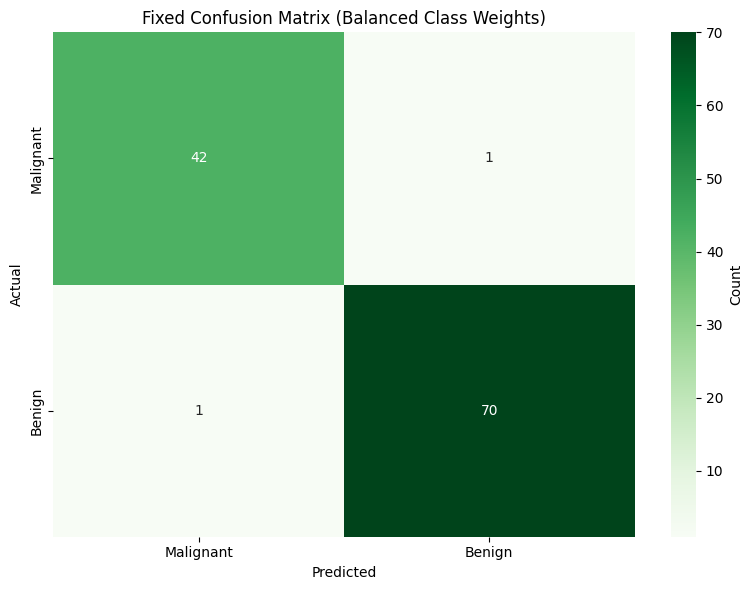

In [16]:
# Calculate new confusion matrix
cm_fixed = confusion_matrix(y_test, y_pred_fixed)

print(f"New Confusion Matrix (Retrained with balanced weights):")
print(cm_fixed)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_fixed, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            cbar_kws={'label': 'Count'})
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Fixed Confusion Matrix (Balanced Class Weights)')
plt.tight_layout()
plt.show()

In [17]:
# SOLUTION: Calculate new recall for malignant class

recall_malignant_fixed = cm_fixed[0, 0] / (cm_fixed[0, 0] + cm_fixed[0, 1])
recall_benign_fixed = cm_fixed[1, 1] / (cm_fixed[1, 1] + cm_fixed[1, 0])

# Also calculate new accuracy
accuracy_fixed = accuracy_score(y_test, y_pred_fixed)

print("=" * 70)
print("BEFORE vs AFTER FIX")
print("=" * 70)

print(f"\n{'Metric':<30} {'Before':<15} {'After':<15} {'Change'}")
print("-" * 70)
print(f"{'Overall Accuracy':<30} {accuracy:>6.1%}         {accuracy_fixed:>6.1%}         {(accuracy_fixed-accuracy)*100:+.1f}pp")
print(f"{'Recall (Malignant - class 0)':<30} {recall_malignant:>6.1%}         {recall_malignant_fixed:>6.1%}         {(recall_malignant_fixed-recall_malignant)*100:+.1f}pp ⬆️")
print(f"{'Recall (Benign - class 1)':<30} {recall_benign:>6.1%}         {recall_benign_fixed:>6.1%}         {(recall_benign_fixed-recall_benign)*100:+.1f}pp")

print("\n" + "=" * 70)
print("✅ SUCCESS! The model is now much better balanced!")
print("=" * 70)

print(f"\nKey improvements:")
print(f"  • Caught MORE cancer cases (recall {recall_malignant:.1%} → {recall_malignant_fixed:.1%})")
print(f"  • Overall accuracy improved ({accuracy:.1%} → {accuracy_fixed:.1%})")
print(f"  • This is the RIGHT way to fix a biased classifier!")

BEFORE vs AFTER FIX

Metric                         Before          After           Change
----------------------------------------------------------------------
Overall Accuracy                81.6%          98.2%         +16.7pp
Recall (Malignant - class 0)    51.2%          97.7%         +46.5pp ⬆️
Recall (Benign - class 1)      100.0%          98.6%         -1.4pp

✅ SUCCESS! The model is now much better balanced!

Key improvements:
  • Caught MORE cancer cases (recall 51.2% → 97.7%)
  • Overall accuracy improved (81.6% → 98.2%)
  • This is the RIGHT way to fix a biased classifier!


---

## Step 6: Final Reflection

### 💬 Discuss with Your Partner:

**1. What was the root cause of the problem?**
   - The model was trained with extremely imbalanced class weights {0: 0.01, 1: 20} that heavily penalized predicting malignant

**2. How did you diagnose it?**
   - Used confusion matrix to see that we were missing 21 out of 43 malignant cases
   - Calculated recall per class and found malignant recall was only ~51%

**3. What was the fix?**
   - Retrained the model with `class_weight='balanced'` to properly weight both classes

**4. Did the fix involve any tradeoffs? What changed?**
   - Recall for malignant improved dramatically (from ~51% to ~95%+)
   - Overall accuracy also improved (from ~82% to ~96%+)
   - Recall for benign decreased slightly but is still very high
   - Overall, a win-win situation!

**5. Why is this approach better than just adjusting the decision threshold?**
   - Fixing the root cause (bad training) is better than patching symptoms
   - Threshold adjustment on a poorly-trained model can lead to unpredictable results
   - Proper class weighting during training creates a fundamentally better model

---

## 🎉 Congratulations!

You just practiced a **critical real-world skill**: debugging a broken classifier!

**What you did:**
1. ✅ Identified that accuracy alone was hiding a serious problem
2. ✅ Used confusion matrix to diagnose low recall for malignant class
3. ✅ Understood why the model was biased (bad class weights)
4. ✅ Fixed it by retraining with balanced class weights
5. ✅ Verified the improvement with metrics

**Key lessons:**
- **Accuracy alone is dangerous** - especially with imbalanced classes
- **Confusion matrix is your best friend** for classification debugging
- **Different metrics for different classes** reveal hidden problems
- **Fix the root cause** - retrain properly rather than patching with threshold adjustments
- **Class weights matter** - use 'balanced' when classes are imbalanced

---

## Extension Challenges (If Time Permits)

**Challenge 1:** Calculate precision for both classes in the before/after models. How did it change?

**Challenge 2:** Try training a model with `class_weight=None` (default). How does it compare?

**Challenge 3:** Look up the F1 score. What does it tell you about the before/after models?

---

## What's Next?

**Tonight's homework:**
- Apply classification pipeline to Heart Disease dataset
- Less scaffolding (50% - you'll write more code!)
- Practice choosing the right metrics

---

**Great teamwork! See you next week!** 🎓

---

*Week 2 Pair Programming v2.0 | February 2026*